## Imports

In [1]:
## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import fiftyone.brain as fob
from sklearn.preprocessing import normalize
import plotly.express as px
import skdim
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ot
from sklearn.manifold import TSNE
import cv2

In [3]:
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("New_Caledonia")
wp_view = dataset.load_saved_view("West_Papua")

In [5]:
## get embeddings for each view and normalize it 
## retrieve values
nc_emb = nc_view.values("full_embeddings")
wp_emb = wp_view.values("full_embeddings")

## convert to array
nc_emb = np.array(nc_emb)
wp_emb = np.array(wp_emb)

## normalize firsrt
nc_norm = normalize(nc_emb)
wp_norm = normalize(wp_emb)


In [8]:
import time
from contextlib import contextmanager

@contextmanager
def timer(name):
    start = time.perf_counter()
    yield
    end = time.perf_counter()
    print(f"{name}: {end - start:.4f} s")
    
def calculate_MLE(dataset: np.ndarray, 
                  list_neighboors: list = [3,5,10,20],
                  verbose=True):
    """
    Computes Maximum Likelihood Estimation for a set of neighboors,
    Returns:
        list of MLE distances for each neighboor
    """
    def compute(dataset, 
                n_neighboors: int,
                n_jobs: int = 1):
        """
        Returns a float containing the intrinsic measure. 
        """
        mlea = skdim.id.MLE().fit_transform(X = dataset,
                                                n_neighbors = n_neighboors,
                                                n_jobs = 1)
        return mlea 
        
    results = {}
    for k in list_neighboors:
        if verbose:
            print(f"running {k}")
            with timer(f'k_{k}'):
                mlea = compute(dataset,
                               n_neighboors = k)
                results[k] = mlea
        else:
            mlea = compute(dataset,
                           n_neighboors = k)
            results[k] = mlea
    return results


## Intrinsic Properties of Image 

- Maximum Likelihood Estimation
- Optimal Transport for Domain Adaptation

### Work Context

We used Dinov3 as a feature extractor for both datasets.
The feature extractor outputs and embedding of size 1024.
- New Caledonia with 716:
  ```python
    np.array(716,1024)
    ```

    
- West Papua with 2450:

    ```python
    np.array(2450,1024)
    ```

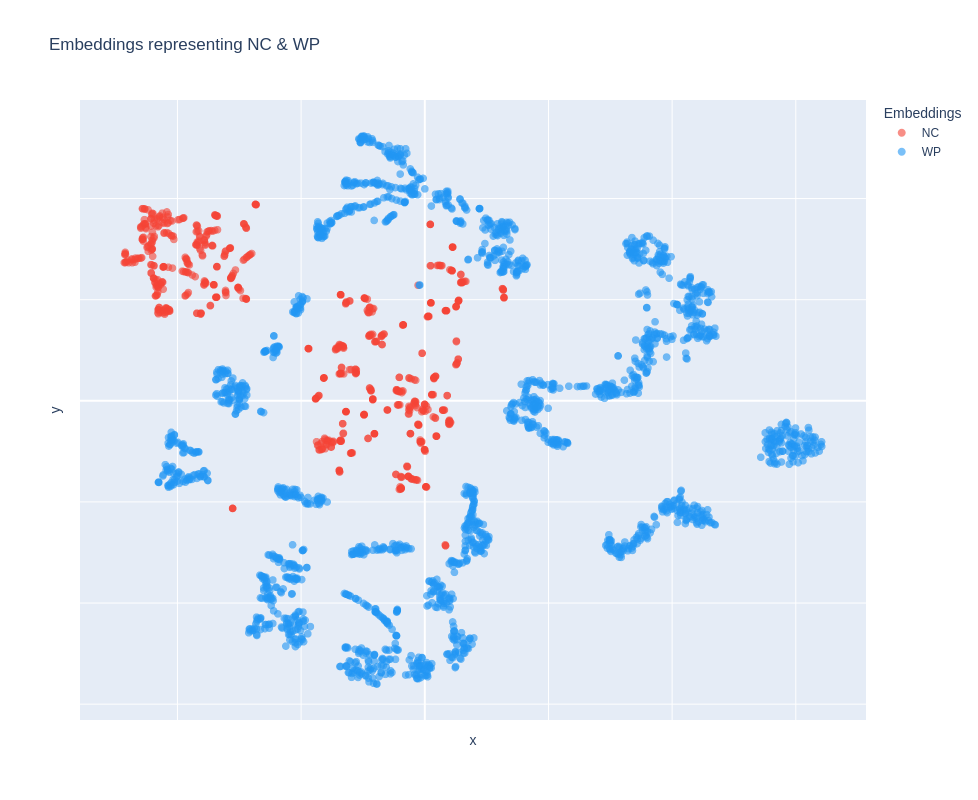

In [6]:
## Full image embeddings 

all_emb = np.vstack([nc_emb, wp_emb])
all_emb_norm = normalize(all_emb)  # L2-normalize before t-SNE


tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, init='pca', learning_rate='auto')
emb_2d = tsne.fit_transform(all_emb_norm)


n_nc = len(nc_emb)
nc_2d = emb_2d[:n_nc]
wp_2d = emb_2d[n_nc:]


df = pd.DataFrame({
    'x': np.concatenate([nc_2d[:,0], wp_2d[:,0]]),
    'y': np.concatenate([nc_2d[:,1], wp_2d[:,1]]),
    'label': ['NC']*n_nc + ['WP']*len(wp_2d)
})


fig = px.scatter(df, x='x', y='y',
                 color='label',
                 color_discrete_map={'NC':'#F44336', 'WP':'#2196F3'},
                 opacity=0.6,
                 size_max=10,
                 title='Embeddings representing NC & WP',
                width=1200,   # increase width
                height=800 
                )

fig.update_traces(marker=dict(size=8,
                              line=dict(width=0)))
fig.update_layout(xaxis=dict(showticklabels=False),
                  yaxis=dict(showticklabels=False),
                  legend=dict(title='Embeddings'))

fig.show()

### Reference work:

- [1] P. Pope, C. Zhu, A. Abdelkader, M. Goldblum, and T. Goldstein, **The Intrinsic Dimension of Images and Its Impact on Learning**, Apr. 18, 2021, arXiv: arXiv:2104.08894. doi: 10.48550/arXiv.2104.08894.
- [2] Y. Lin, Z. Zhu, Y. Guo, Z. Ou, S. Yao, and M. Song, **Exploring Inter-Domain Wasserstein Metric for Adaptive Object Detection**, IEEE Trans. Multimedia, pp. 1–11, 2026, doi: 10.1109/TMM.2026.3668648.


### Intrinsic Dimensions

> "...Find that the intrinsic dimension of internal representations is **inversely correlated with high performance**, we study the dimensionality of data and its impact on performance, and we make a similar finding..."
> (Pope et. al, 2021)
>
> "Additionally, we find that **low dimensional datasets are easier for neural networks to learn**, and models solving these tasks generalize better from training to test data"
> (Pope et. al, 2021) 

#### Intrinsic Dimension Estimation 

 - "One of the main approaches to intrinsic dimension estimation is to examine a neighborhood around each point in the dataset, and compute the Euclidean distance to the $k_{th}$ nearest neighbor."

     - 1 . **Maximum Likelihood Estimation**


### Maximum Likelihood Estimation

- Levina & Bickel (2005) uses a Poisson process to model the number of points found by random sampling within a given radius around each sample point.

By relating the rate of this process to the surface area of the sphere, the likelihood equations yield an estimate of the ID at a given point $x$ as:

$$
\hat{m}_k(x) = \left[ \frac{1}{k-1} \sum_{j=1}^{k-1} \log \frac{T_k(x)}{T_j(x)} \right]^{-1}, \tag{1}
$$

Where:
* **$T_j(x)$** is the Euclidean ($\ell_2$) distance from $x$ to its $j^{th}$ nearest neighbor.
* **$k$** is the number of neighbors considered.


> "As shown by MacKay & Ghahramani (2005), the positive bias of the corrected estimator Equation (2) increases as k increases, but the variance decreases. In order to navigate this bias-variance tradeoff, we try various values of k."

Assumptions:
    - MLE assumes data to be *i.i.d*


- **Global Intrinsic Dimension Estimate**

Levina & Bickel (2005) propose averaging the local estimates across all sample points to obtain a global estimate:

$$
\bar{m}_k = \frac{1}{n} \sum_{i=1}^{n} \hat{m}_k(x_i)
$$

where ($(\hat{m}_k(x_i)$) is the local intrinsic dimension estimate at point $(x_i)$.


**Inverse Averaging Correction**

MacKay & Ghahramani (2005) suggest a correction based on averaging the **inverse** of the local estimates:

$$
\bar{m}_k =
\left[
\frac{1}{n}
\sum_{i=1}^{n}
\hat{m}_k(x_i)^{-1}
\right]^{-1}
$$



- Expanded Expression

Substituting the local estimator definition gives:

$$
\bar{m}_k =
\left[
\frac{1}{n(k-1)}
\sum_{i=1}^{n}
\sum_{j=1}^{k-1}
\log \frac{T_k(x_i)}{T_j(x_i)}
\right]^{-1}
\tag{2}
$$

where:

- \(T_j(x_i)\) is the distance from \(x_i\) to its \(j\)-th nearest neighbor  
- \(k\) is the neighborhood size

---
Thankfully, **scikit-dimension** provides this method implemented

In [9]:
# Compute MLE for whole dataset 
datasets_l ={'WP': wp_norm, 
             'NC' : nc_norm}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[3,5,10,20],
                           verbose=False)
    output[k] = results


## throw in a df
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

df_melted = df.melt(id_vars = 'N_neighboor',
                    var_name='Group',
                    value_name='Value'
                   )

df_melted

Running:WP
Running:NC


,N_neighboor,Group,Value
0,3,WP,21.865631
1,5,WP,13.538081
2,10,WP,9.751830
3,20,WP,7.632002
4,3,NC,8.292437
5,5,NC,5.226210
6,10,NC,4.454949
7,20,NC,5.131907


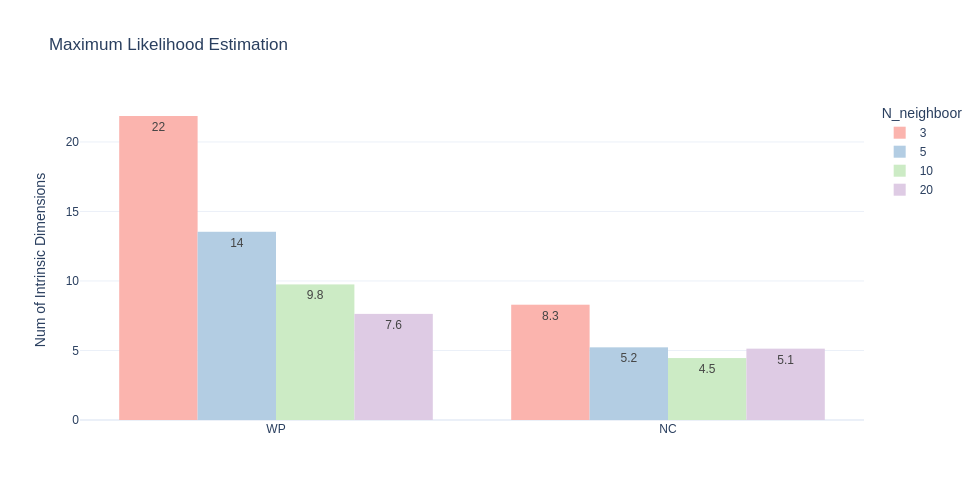

In [10]:
fig = px.histogram(
    df_melted,
    x="Group",          # categories on x-axis
    y="Value",          # numeric values on y-axis
    color="N_neighboor",
    barmode="group",
  ##  orientation="v",
    text_auto='.2s',
    color_discrete_sequence=px.colors.qualitative.Pastel1,  # palette
    title="Maximum Likelihood Estimation",
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title="Num of Intrinsic Dimensions",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

#### Question:

- What if I sample 100 samples on each dataset and randomly select them to calculate MLE, would it converge?

```python
# configuration
n_iterations = 100
sample_size = 100
neighbors = [3, 5, 10, 20]
```

In [11]:
## Calculate for 100 samples of each dataset
datasets_l ={'WP': wp_norm, 
             'NC' : nc_norm}
n_iterations = 100
sample_size = 100
neighbors = [3, 5, 10, 20]
all_results = []

for name, data in datasets_l.items():
    print(f"Processing Distribution for: {name}")
    
    for i in range(n_iterations):
        # randomly sample indices
        indices = np.random.choice(data.shape[0], size=sample_size, replace=False)
        sample = data[indices]
        
        # MLE
        res = calculate_MLE(dataset=sample,
                             list_neighboors=neighbors,
                             verbose=False)
        
        #df
        for k_nn, val in res.items():
            all_results.append({
                'Dataset': name,
                'k_neighbors': k_nn,
                'MLE_Value': val,
                'Iteration': i
            })

# create df
df_dist = pd.DataFrame(all_results)

Processing Distribution for: WP
Processing Distribution for: NC


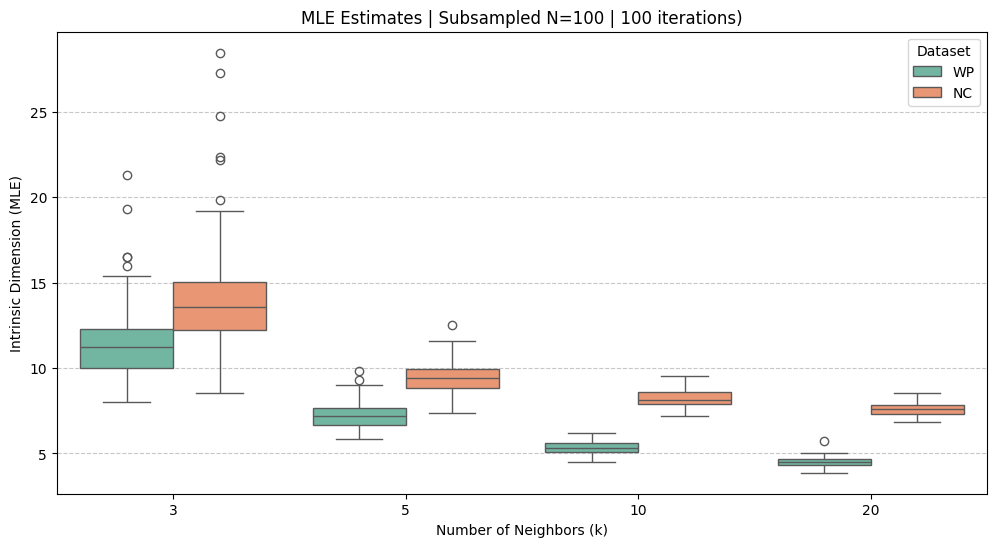

In [12]:
## plot
plt.figure(figsize=(12, 6))

# Boxplot shows the quartiles and outliers clearly
sns.boxplot(data=df_dist,
             x='k_neighbors',
               y='MLE_Value',
                 hue='Dataset',
                   palette='Set2')

plt.title(f'MLE Estimates | Subsampled N={sample_size} | {n_iterations} iterations)')
plt.ylabel('Intrinsic Dimension (MLE)')
plt.xlabel('Number of Neighbors (k)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Question:

- Perhaps should defined a convergence for a given amount of sample.

Boostrap
```python
sample_sizes = [50, 100, 250, 500, 700]
neighbors_list = [3, 5, 10, 20]
n_iterations = 15
```

In [13]:
# Configuration
sample_sizes = [50, 100, 250, 500, 700]
neighbors_list = [3, 5, 10, 20]
n_iterations = 15

results_list = []

for name, data in datasets_l.items():
    print(f"Processing: {name}")
    for n in sample_sizes:
        if n > data.shape[0]: continue 
        
        for i in range(n_iterations):
            idx = np.random.choice(data.shape[0], size=n, replace=False)
            # Calculate MLE for all k at once for this specific sample
            res = calculate_MLE(dataset=data[idx],
                                 list_neighboors=neighbors_list,
                                 verbose=False)
            
            for k, val in res.items():
                results_list.append({
                    'Dataset': name,
                    'Sample Size': n,
                    'k': k,
                    'MLE': val
                })

df_interaction = pd.DataFrame(results_list)


Processing: WP
Processing: NC


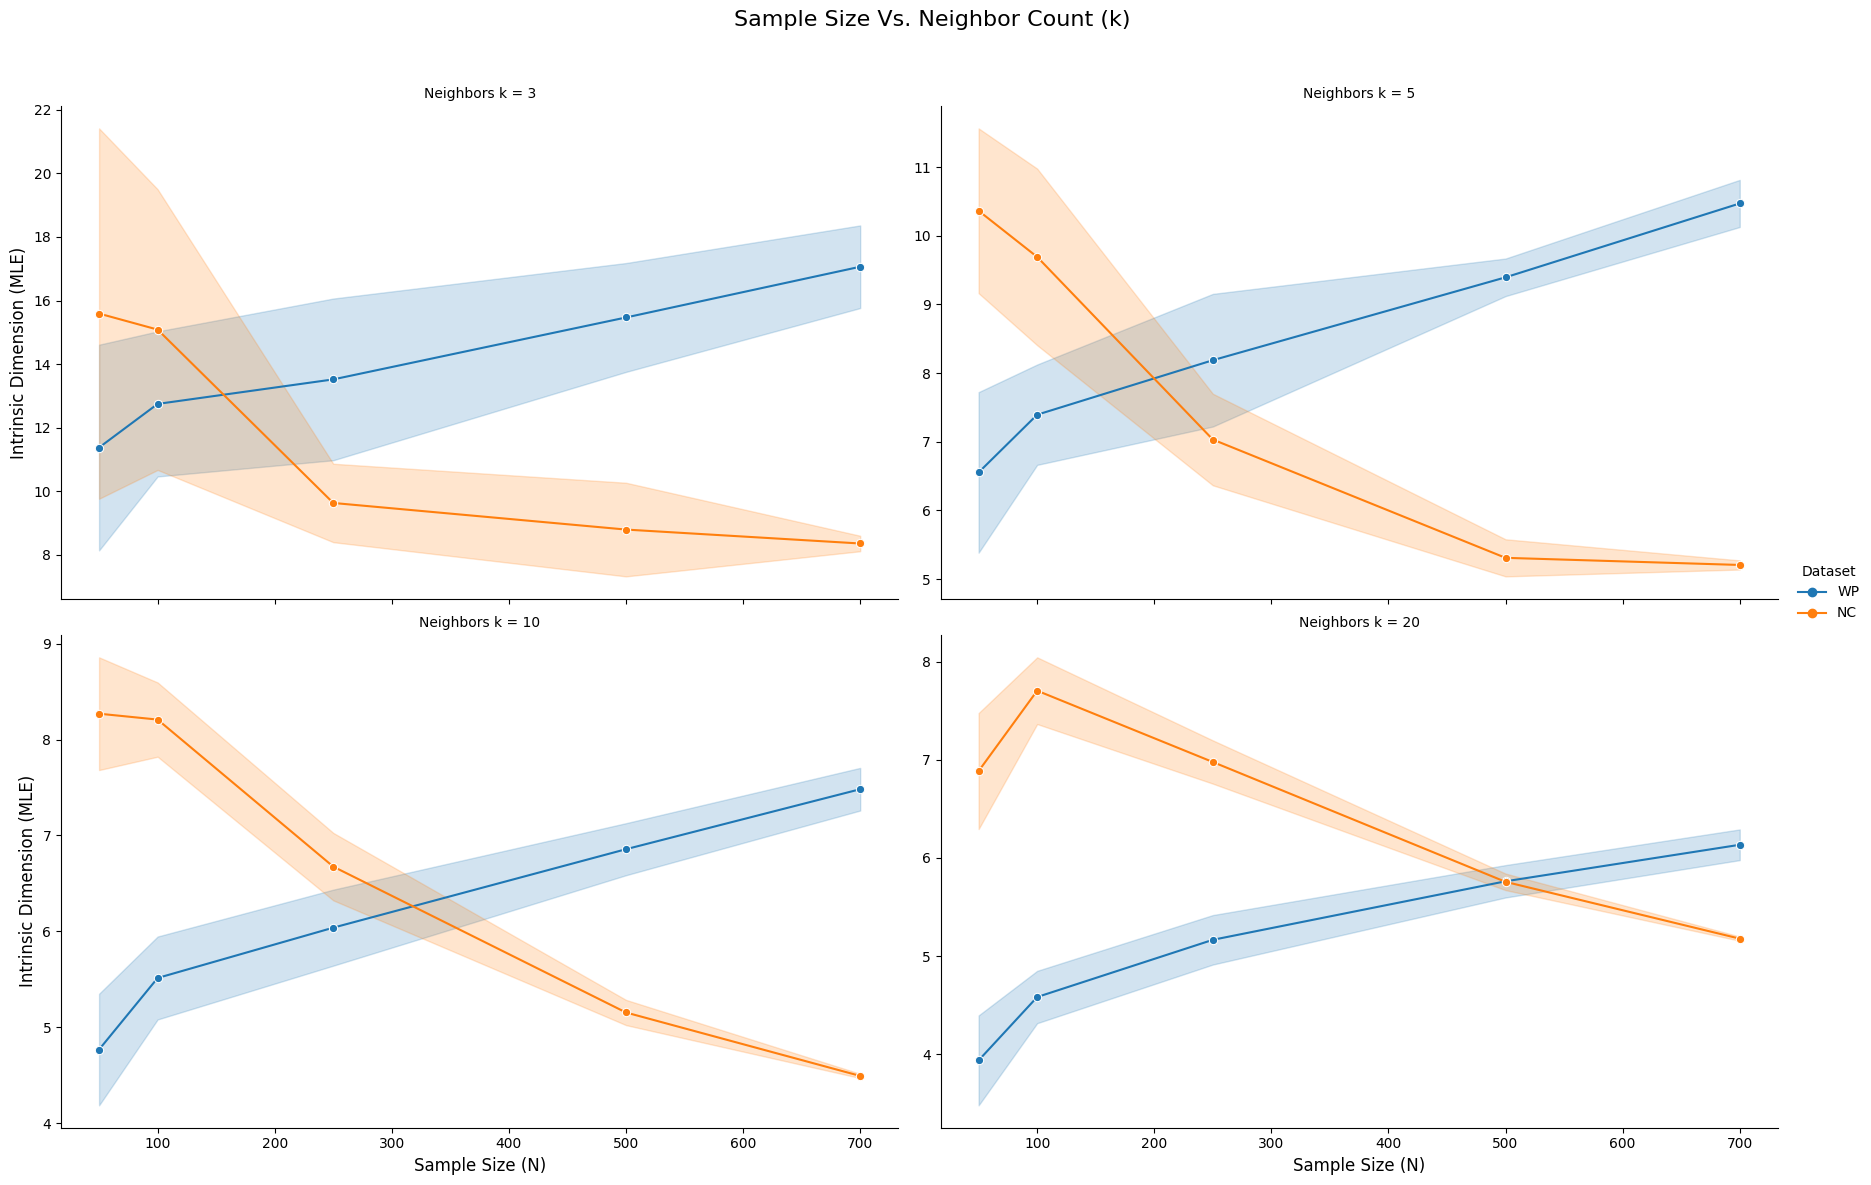

In [14]:
# plot
g = sns.relplot(
    data=df_interaction, 
    x='Sample Size', 
    y='MLE', 
    hue='Dataset', 
    col='k', 
    kind='line', 
    marker='o', 
    facet_kws={'sharey': False},
    errorbar='sd',
    col_wrap = 2,
    height = 6,
    aspect = 1.5
)

g.set_axis_labels("Sample Size (N)", "Intrinsic Dimension (MLE)",
                 fontsize=12)
g.set_titles("Neighbors k = {col_name}",fontsize=20)
plt.subplots_adjust(top=0.90)
g.fig.suptitle('Sample Size Vs. Neighbor Count (k)',fontsize=16)

plt.show()

#### Discussion:

Interplay between: **local density**, **sampling bias** and **scale of observation**.

MLE assumes that points are sampled from a smooth manifold and the neighborhood is flat enough to behave like Euclidean space. 

When $N<<$ small (100) for a complex dataset, the points are very far apart. The manifold loks like a sparse cloud of isolated points rather than continuous surface. 

In case NC is more compact or has higher density in cetain regions, 100 samples would be enough to start seeing its structure.

As $N$ increases, the average distance to the $k$-th neighbor decreases. You are essentially "zooming in." Once you have enough points, the true underlying complexity of the 2500-image manifold finally becomes visible, and it overtakes the smaller dataset.

---
Outcomes:

Given MLE analysis, West Papua has more latent complexity, but it can be only perceive when sampling density $N$ is high enough to satify the k neighbors.

## Optimal Transport 

Earth Mover's Problem:
    Imagine you have 716 piles of sand (NC images) and 2039 holes (WP images).
    Each pile and each hole has a fixed amount of sand (mass). The question OT asks is:

        What is the cheapest way to move all the sand from the piles into the holes?

It is a measure of dissimilarity between two disjoint subsets, densities, or measures, over a metric space $D$.

"Cheap" means minimizing the total mass × distance traveled. 


> "Consequently, the discrepancy between image  datasets can be abstracted as the distance between discrete  distributions in the standard metric space."
> Lin et al. 2026

### Cost Matrix $M$

Suppose that we have a collection of $m$ mines mining iron ore, and a collection of $n$ factories which use the iron ore. The factory and mines are two disjoint subsets $M$ and $F$. Suppose we have a cost function: $c: R^2 X R^2 -> [0,inf] $ . So that $c(x,y)$ is the cost of transporting one shipment of iron from $x$ to factory $y$. 

*Boundaries*: We also assume that each mine can supply only one factory (no splitting of shipments) and that each factory requires precisely one shipment to be in operation (factories cannot work at half- or double-capacity). 

The transport plan is a bijection. $T: M \to F $ . The solution is a transport plan, the plan $T$ whose total cost:
$$
c(T) := \sum_{m \in M} c(m, T(m))
$$




---
Hence, given the cost matrix $M$, Optimal Transport (OT) solves:

$$
\min_{T \geq 0} \sum_{i,j} T_{ij} \cdot M_{ij}
$$

subject to the marginal constraints: (transporting from NC to WP)

$$
\sum_j T_{ij} = a_i \quad \text{(all NC mass is shipped out)}
$$

$$
\sum_i T_{ij} = b_j \quad \text{(all WP mass is received)}
$$

where: (uniform weights = equally distributed mass)

$$
a_i = \frac{1}{716}, \qquad b_j = \frac{1}{2039}
$$


---
The cost matrix for an **euclidean** approach:

$$
M_{ij} = c(x_i^{NC}, x_j^{WP})
$$

For metric='sqeuclidean':
$$
M_{ij} = \| \mathbf{x}_i^{NC} - \mathbf{x}_j^{WP} \|_2^2
$$

---

**Wasserstein Metric**

$$
W[S, T] = \min_{P} \langle \text{C}, \text{P} \rangle
$$
The distance between $S$ and $T$. Where $C$ is the cost matrix and $P$ is the coupling matrix, or the transport plan, and the $\min_{P}$ is the optimal transportation scheme. 

Wassertein Distance: 0.328550


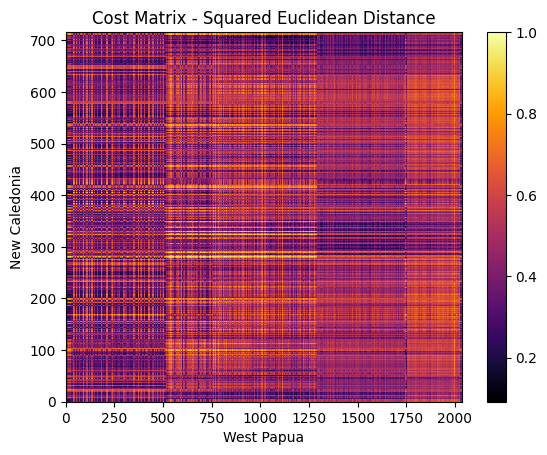

In [15]:
## Cost Matrix of Euclidean Distance
source = nc_norm
target = wp_norm
M = ot.dist(source,
            target,
            metric='sqeuclidean')

M /= M.max()  # normalize

## The Wassertein distance of NC and WP
# Uniform weights — each point gets equal mass, summing to 1
a = ot.unif(source.shape[0])   # shape (716,), each entry = 1/716
b = ot.unif(target.shape[0])  # shape (2039,), each entry = 1/2039

# Wasserstein distance
W = ot.emd2(a, b, M)
print(f"Wassertein Distance: {W:4f}")

plt.pcolormesh(M, cmap='inferno')
plt.colorbar()
plt.ylabel('New Caledonia')
plt.xlabel('West Papua')
plt.title("Cost Matrix - Squared Euclidean Distance")
plt.show()


### Transport Embeddings

In [16]:
with timer("Time taken to transport NC -> WP: "):
    ot_lpl1 = ot.da.SinkhornTransport(reg_e=0.05,
                                      max_iter = 1500,
                                      verbose=False,
                                      tol = 1e-8,
                                      )
    
    norm_nc = normalize(nc_emb)
    norm_wp = normalize(wp_emb)
    ot_lpl1.fit(Xs=norm_nc,
                Xt=norm_wp)

    nc_adapted = ot_lpl1.transform(Xs=norm_nc)  # shape (716, 1024)

    ## get the optimal transport plan
    ## coupling matrix
    coupling = ot_lpl1.coupling_

Time taken to transport NC -> WP: : 14.8794 s


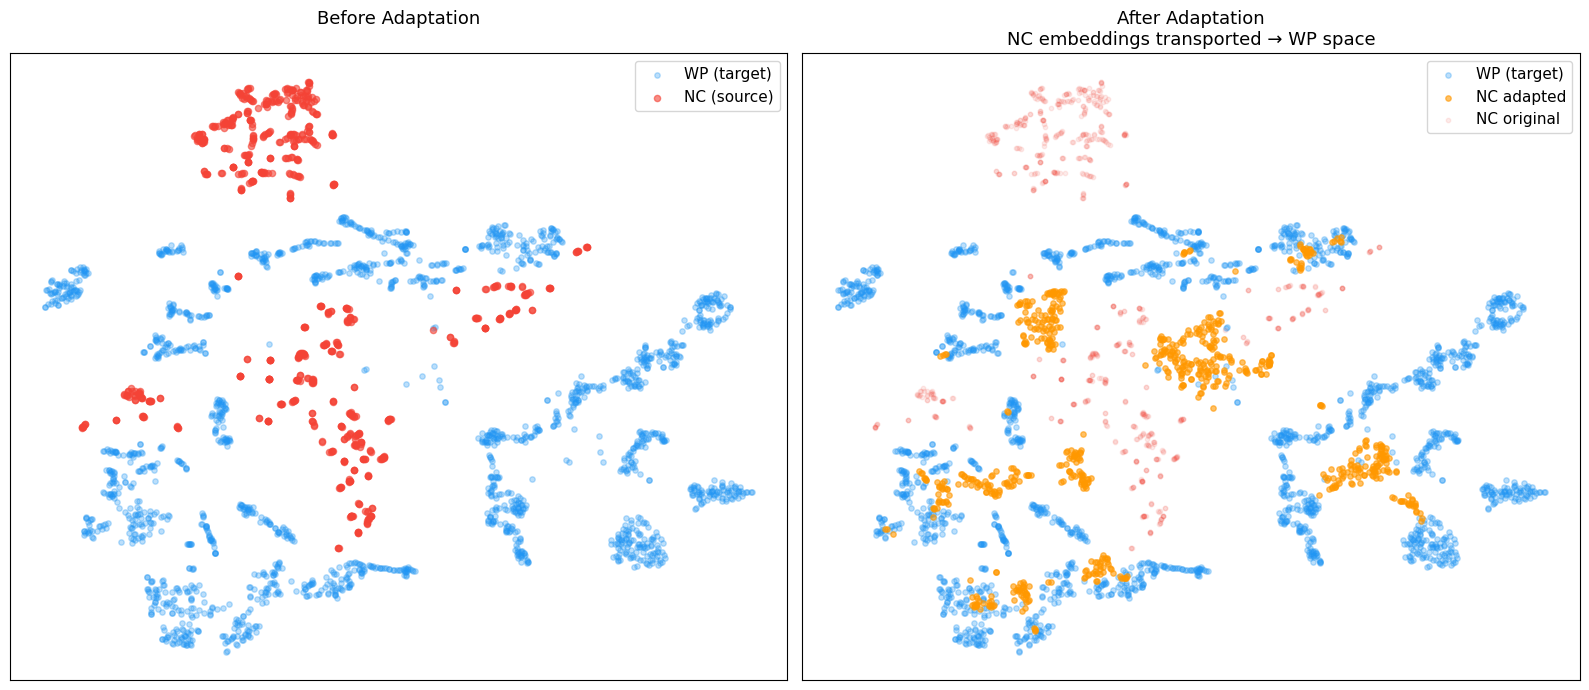

In [17]:
all_emb = np.vstack([nc_emb, nc_adapted, wp_emb])
all_emb_norm = normalize(all_emb)  # L2-normalize before t-SNE

## compute tsne on embeddings 
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, init='pca', learning_rate='auto')
emb_2d = tsne.fit_transform(all_emb_norm)

# Split back
n_nc = len(nc_emb)
n_wp = len(wp_emb)
nc_2d     = emb_2d[:n_nc]
nc_ad_2d  = emb_2d[n_nc:n_nc*2] ## adapated nc
wp_2d     = emb_2d[n_nc*2:]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Before adaptation ---
ax = axes[0]
ax.scatter(wp_2d[:, 0],    wp_2d[:, 1],    c='#2196F3', alpha=0.3, s=15, label='WP (target)')
ax.scatter(nc_2d[:, 0],    nc_2d[:, 1],    c='#F44336', alpha=0.6, s=20, label='NC (source)')
ax.set_title('Before Adaptation\n', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

# --- After adaptation ---
ax = axes[1]
ax.scatter(wp_2d[:, 0],    wp_2d[:, 1],    c='#2196F3', alpha=0.3, s=15, label='WP (target)')
ax.scatter(nc_ad_2d[:, 0], nc_ad_2d[:, 1], c='#FF9800', alpha=0.6, s=15, label='NC adapted')
ax.scatter(nc_2d[:, 0],    nc_2d[:, 1],    c='#F44336', alpha=0.1, s=10, label='NC original')
ax.set_title('After Adaptation\nNC embeddings transported → WP space', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


### Domain Adaptation - Style Transfering

Optimal transport is broadly used for domain adaptation tasks.
Here, we step back with embeddings and get two images to illustrate an domain adaptation case.



In [18]:

rng = np.random.RandomState(42)


def im2mat(img):
    """Converts and image to matrix (one pixel per line)"""
    return img.reshape((img.shape[0] * img.shape[1], img.shape[2]))


def mat2im(X, shape):
    """Converts back a matrix to an image"""
    return X.reshape(shape)


def minmax(img):
    return np.clip(img, 0, 1)

In [19]:

I1 = cv2.cvtColor(cv2.imread(wp_view.first().filepath),
                        cv2.COLOR_BGR2RGB) / 256
I2 = cv2.cvtColor(cv2.imread(nc_view.first().filepath),
                        cv2.COLOR_BGR2RGB) / 256

X1 = im2mat(I2)
X2 = im2mat(I1)

# # training samples
## uses 500 samples to train the OT 
## here it is sampling the X1 matrix where each line is a pixel [r,g,b]
nb = 500
idx1 = rng.randint(X1.shape[0], size=(nb,))
idx2 = rng.randint(X2.shape[0], size=(nb,))

Xs = X1[idx1, :]
Xt = X2[idx2, :]

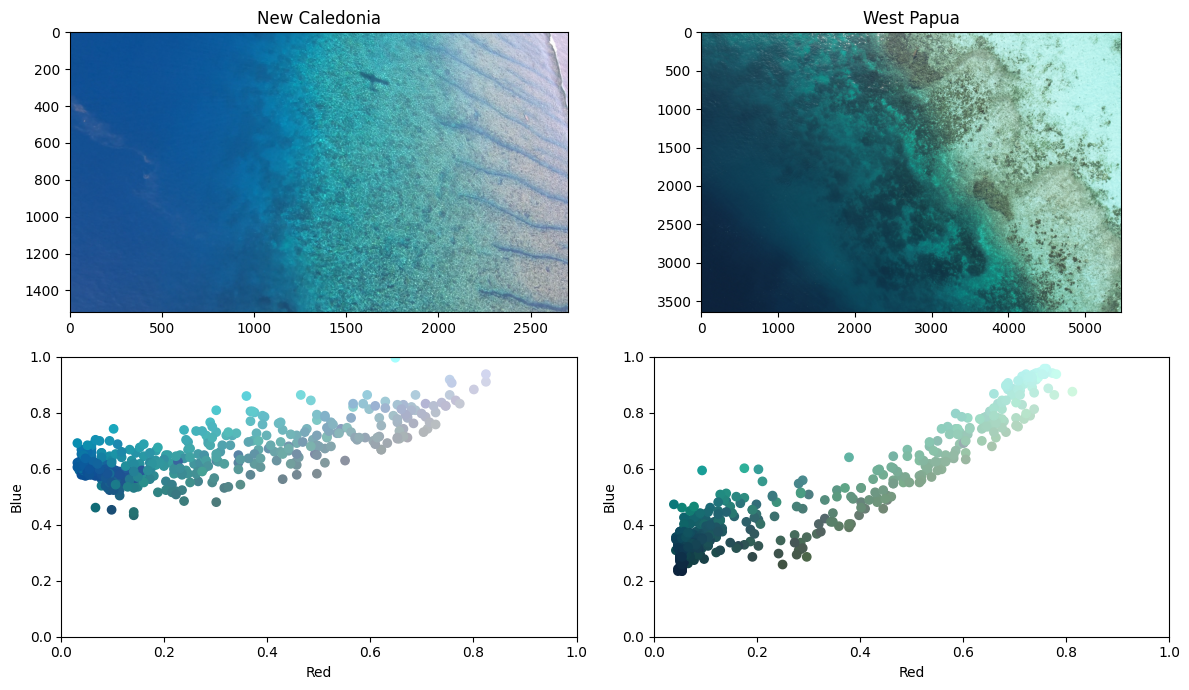

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].imshow(I2)
ax[0,0].set_title('New Caledonia')
ax[0,1].imshow(I1)
ax[0,1].set_title('West Papua')

ax[1,0].scatter(Xs[:, 0], Xs[:, 2], c=Xs)
ax[1,0].axis([0, 1, 0, 1])
ax[1,0].set_xlabel("Red")
ax[1,0].set_ylabel("Blue")

ax[1,1].scatter(Xt[:, 0], Xt[:, 2], c=Xt)
ax[1,1].axis([0, 1, 0, 1])
ax[1,1].set_xlabel("Red")
ax[1,1].set_ylabel("Blue")
plt.tight_layout()
fig.show()

EMDTransport: 39.5695 s
SinkhornTransport: 11.3569 s
It.  |Loss        |Delta loss
--------------------------------
    0|3.218774e+01|0.000000e+00
    1|3.177746e+01|-1.274622e-02
    2|3.174314e+01|-1.080020e-03
    3|3.173019e+01|-4.080368e-04
    4|3.172344e+01|-2.128934e-04
    5|3.171940e+01|-1.272037e-04
    6|3.171676e+01|-8.335639e-05
    7|3.171484e+01|-6.055938e-05
    8|3.171343e+01|-4.438903e-05
    9|3.171228e+01|-3.624677e-05
   10|3.171136e+01|-2.885261e-05
   11|3.171060e+01|-2.419881e-05
   12|3.170998e+01|-1.943394e-05
   13|3.170943e+01|-1.735518e-05
   14|3.170899e+01|-1.397270e-05
   15|3.170859e+01|-1.257570e-05
   16|3.170826e+01|-1.017233e-05
   17|3.170814e+01|-4.070206e-06
Mapping Linear: 4.8106 s
It.  |Loss        |Delta loss
--------------------------------
    0|3.414097e+01|0.000000e+00
    1|3.277847e+01|-3.990806e-02
    2|3.266834e+01|-3.359709e-03
    3|3.263995e+01|-8.690353e-04
    4|3.262773e+01|-3.744765e-04
    5|3.262097e+01|-2.070884e-04
    6|

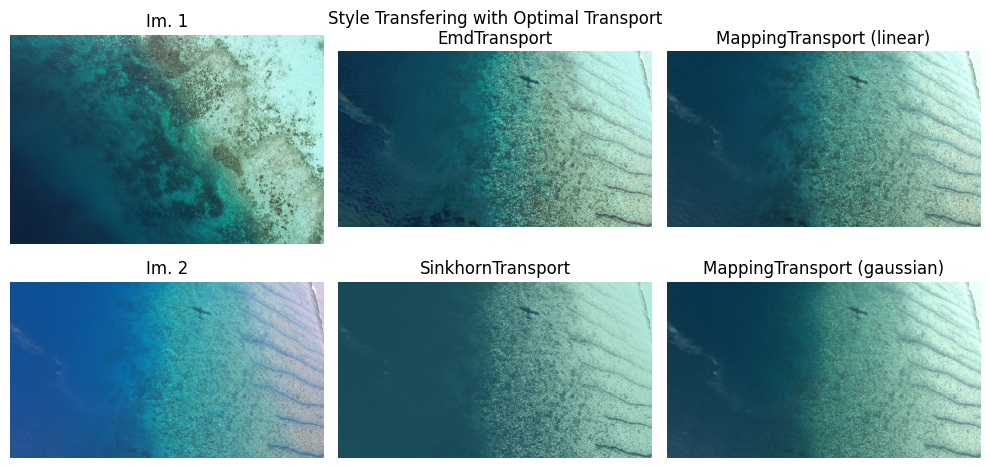

In [24]:
with timer("EMDTransport"):
    ot_emd = ot.da.EMDTransport(verbose=False)
    ot_emd.fit(Xs=Xs, Xt=Xt)
    transp_Xs_emd = ot_emd.transform(Xs=X1)
    Image_emd = minmax(mat2im(transp_Xs_emd, I2.shape))


with timer("SinkhornTransport"):
    ot_sinkhorn = ot.da.SinkhornTransport(reg_e=1e-1, verbose=False)
    ot_sinkhorn.fit(Xs=Xs, Xt=Xt)
    transp_Xs_sinkhorn = ot_sinkhorn.transform(Xs=X1)
    Image_sinkhorn = minmax(mat2im(transp_Xs_sinkhorn, I2.shape))


with timer("Mapping Linear"):
    ot_mapping_linear = ot.da.MappingTransport(
        mu=1e0, eta=1e-8, bias=True, max_iter=20, verbose=False
    )
    ot_mapping_linear.fit(Xs=Xs, Xt=Xt)
    X1tl = ot_mapping_linear.transform(Xs=X1)
    Image_mapping_linear = minmax(mat2im(X1tl, I2.shape))


with timer("Mapping Gaussian"):
    ot_mapping_gaussian = ot.da.MappingTransport(
        mu=1e0, eta=1e-2, sigma=1, bias=False, max_iter=10, verbose=False
    )
    ot_mapping_gaussian.fit(Xs=Xs, Xt=Xt)
    X1tn = ot_mapping_gaussian.transform(Xs=X1)
    Image_mapping_gaussian = minmax(mat2im(X1tn, I2.shape))


plt.figure(2, figsize=(10, 5))

plt.subplot(2, 3, 1)
plt.imshow(I1)
plt.axis("off")
plt.title("Im. 1")

plt.subplot(2, 3, 4)
plt.imshow(I2)
plt.axis("off")
plt.title("Im. 2")

plt.subplot(2, 3, 2)
plt.imshow(Image_emd)
plt.axis("off")
plt.title("EmdTransport")

plt.subplot(2, 3, 5)
plt.imshow(Image_sinkhorn)
plt.axis("off")
plt.title("SinkhornTransport")

plt.subplot(2, 3, 3)
plt.imshow(Image_mapping_linear)
plt.axis("off")
plt.title("MappingTransport (linear)")

plt.subplot(2, 3, 6)
plt.imshow(Image_mapping_gaussian)
plt.axis("off")
plt.title("MappingTransport (gaussian)")
plt.tight_layout()

plt.suptitle("Style Transfering with Optimal Transport")
plt.show()

### Notes:

- Here we denote that:
- Optimal Transport has several solvers.
- The cost matrix does necessary implies on euclidean approach.
- The dimension of the image (embedding or RGB channel) modifies the downstream task,

The article from (Y. Lin et al, 2026), *‘Exploring Inter-Domain Wasserstein Metric for Adaptive Object Detection’* uses Wasserstein metric and propose this metric as a universal metric for measuring inter-domain discrepancies based on Wasserstein. They use OT as a assistant domain to conduct domain knowledge transfer. 

![img](assistant_domain.png)


### SSIM 

The biggest innovation presented by the paper highlights the fact given by the cost matrix. Instead of using euclidean, they are using a **structural similarity index measure (SSIM)**. 

$$
l(x, y) = \frac{2 \mu_x \mu_y + C_1}{\mu_x^2 + \mu_y^2 + C_1}
$$

$$
c(x, y) = \frac{2 \sigma_x \sigma_y + C_2}{\sigma_x^2 + \sigma_y^2 + C_2}
$$

$$
s(x, y) = \frac{\sigma_{xy} + C_3}{\sigma_x \sigma_y + C_3}
$$

$$
\text{SSIM}(x, y) = [l(x, y)]^\alpha \, [c(x, y)]^\beta \, [s(x, y)]^\gamma
$$

where $x$ and $y$ are images from the source and target domain image datasets. Respectively, $\mu_x$ and $\mu_y$ represent the **mean** pixel values of the images, $\sigma_x$ and $\sigma_y$ represent the **standard deviations** of the image pixel values.  $\sigma_xy$ represents the  **covariance** of the pixels between the two images, and C1,  C2, C3 are small constants close to 0. 

Then l, c and s denote the **similarity in brightness, contrast, and structure between**  images, respectively.

## Next Steps

- Compute SSIM pairwise for the datasets.
- Incorporate the SSIM in a cost matrix and calculate the optimal transport plan. 
- Undertand what other metrics besides euclidean space could be use to characterize embeddings and therefore provide another cost matrix. ( Cosine Similarity (Angular Distance))

## Hypothetical Scenario

Context:

Dugongs are endangered marine species  population and reliant on specific habitats.

Let’s imagine that:

* Region A (Source Domain): A comprehensive aerial survey of Dugongs is conducted over the waters surrounding New Caledonia. This dataset is used to train a deep learning model for automatic Dugong detection in drone imagery. The model performs well, thanks to the high-quality labeled data gathered during the survey.

* Region B (Target Domain): Now, the monitoring effort expands to a new geographic location, West Papua. This region is similar in broad ecological terms but introduces substantial differences in environmental factors:  

    a: Water turbidity alters color and brightness in the imagery.
    b: Dugongs might occupy subtly different habitats, affecting image structure (e.g., shadows, seagrass patterns).
    c: Flight heights, sunlight angles, and the presence of calves introduce additional variability.

When the New Caledonia-trained model is applied to this new dataset, its performance drops significantly, due to domain shift. Intrinsic properties of the drone imagery—brightness, contrast, structure—differ significantly between the two regions, making it harder for the model to generalize.


Research Motivation:

Fine-tuning the model using Region B imagery is necessary. However, labeling new data is time-consuming and expensive.
This leads to the central question:

**Is there a way to select a small, optimal subset of images from the new dataset that maximizes the model’s fine-tuning performance?** 


Key Questions:

1. Can intrinsic properties of the images (brightness, contrast, or structural features) be used to identify highly representative samples? Do these properties help capture the diversity of Region B while minimizing redundancy?

2. Can metrics like the Wasserstein Distance quantify the shift between Region A and Region B embeddings, while guiding the selection of samples that best bridge the domain gap?
  
3. How do intrinsic properties and dataset alignment strategies impact the transferability of the model?

In [2]:
## Thank you